# Layer 3 – GNN Root Cause Analysis

Industry-grade training notebook with data engineering, visualization, training, and evaluation.

## 1. Environment Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nb_dir = Path.cwd()
project = nb_dir
while project.parent != project:
    if (project / "backend" / "main.py").exists():
        break
    project = project.parent
backend = project / "backend"
for p in (project, backend):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

ARTIFACTS = backend / "artifacts"
DATA = project / "data"
DATASETS = DATA / "datasets"
MASTER = DATA / "master"
EVAL = DATA / "evaluation"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

from scripts.synthetic_data import load_dataset, persist_all_datasets
if not (MASTER / "industrial_master.csv").exists():
    persist_all_datasets(DATASETS)

MODEL_KEY = "gnn_rca"
TRAIN_CSV = DATASETS / MODEL_KEY / "train.csv"
TEST_CSV  = DATASETS / MODEL_KEY / "test.csv"
train_npz = load_dataset(MODEL_KEY, DATASETS, split="train")
test_npz  = load_dataset(MODEL_KEY, DATASETS, split="test")
print("Project:", project)
print("Train shape:", train_npz["X"].shape)
print("Test shape:", test_npz["X"].shape)
sns.set_theme(style="whitegrid")

Project: c:\Users\ASUS\Downloads\tata-steel-round -2\industrial-agentic-maintenance-ai
Train shape: (3590, 3)
Test shape: (770, 3)


## 2. Data Engineering & Exploratory Analysis

Master records: 52,000 | Assets: 520


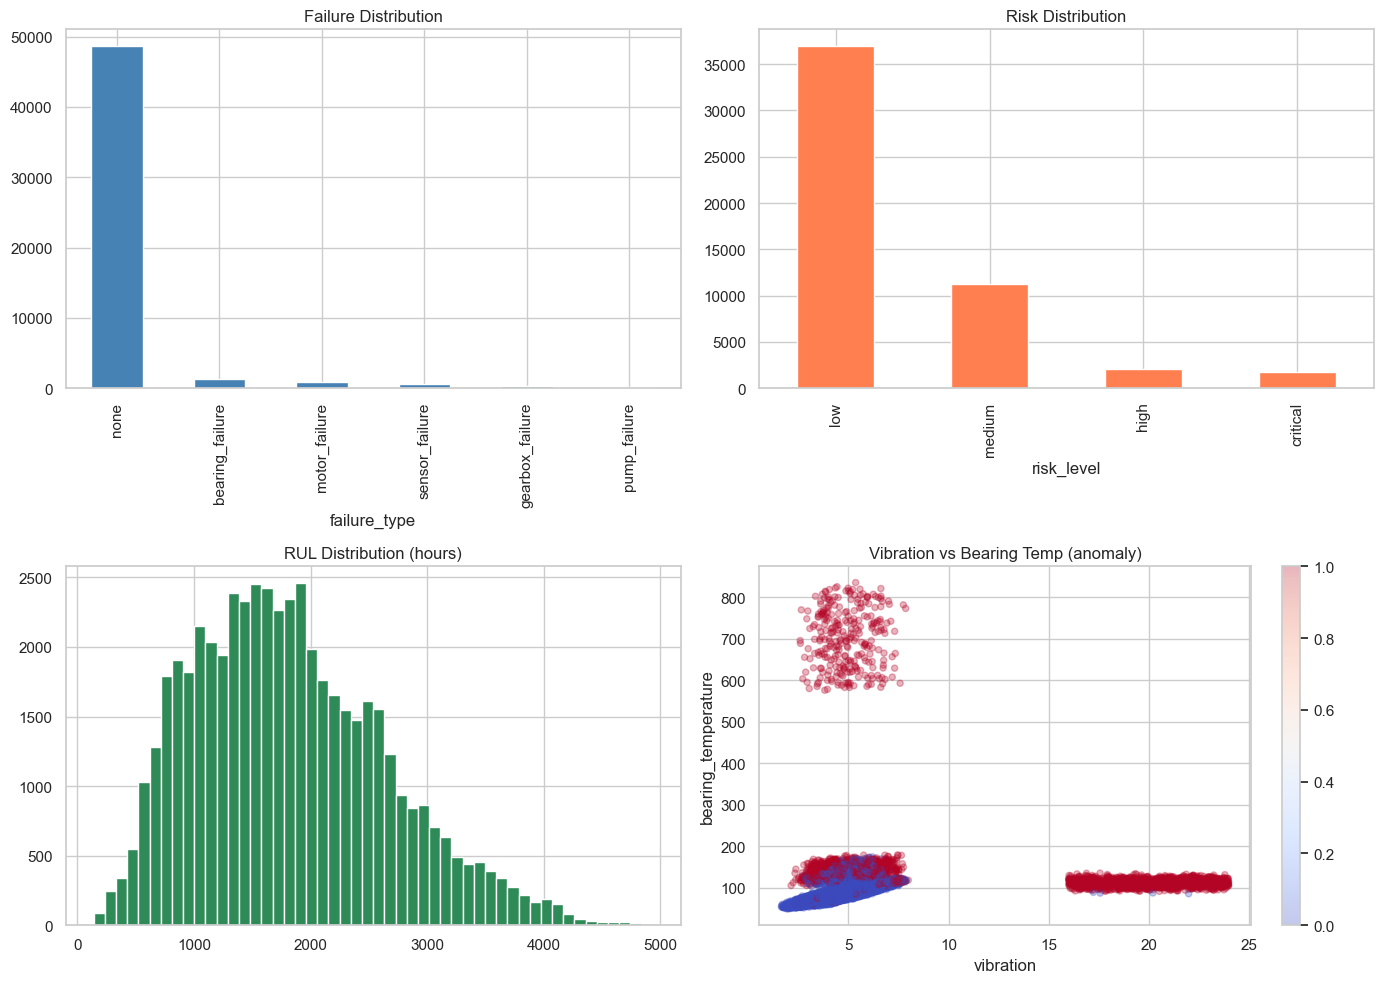

,f0,f1,f2,target
0,94.74017,17.17491,39.20834,Insufficient Lubrication
1,92.73445,17.17491,39.20834,Insufficient Lubrication
2,92.17077,22.17491,39.20834,Insufficient Lubrication
3,93.49340,17.17491,39.20834,Insufficient Lubrication
4,94.87571,17.17491,39.20834,Insufficient Lubrication


In [2]:
# --- Data Engineering & EDA ---
master = pd.read_csv(MASTER / "industrial_master.csv", parse_dates=["timestamp"])
print(f"Master records: {len(master):,} | Assets: {master['equipment_id'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
master["failure_type"].value_counts().plot(kind="bar", ax=axes[0,0], title="Failure Distribution", color="steelblue")
master["risk_level"].value_counts().plot(kind="bar", ax=axes[0,1], title="Risk Distribution", color="coral")
axes[1,0].hist(master["remaining_useful_life_hours"], bins=50, color="seagreen", edgecolor="white")
axes[1,0].set_title("RUL Distribution (hours)")
master.plot.scatter(x="vibration", y="bearing_temperature", c=master["is_anomaly"], cmap="coolwarm", alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Vibration vs Bearing Temp (anomaly)")
plt.tight_layout()
plt.savefig(DATASETS / MODEL_KEY / "eda_overview.png", dpi=120)
plt.show()

if TRAIN_CSV.exists():
    try:
        from IPython.display import display
        display(pd.read_csv(TRAIN_CSV).head())
    except ImportError:
        print(pd.read_csv(TRAIN_CSV).head())

## 3. Model Training & Evaluation

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

nodes_train = pd.read_csv(DATASETS / MODEL_KEY / "train_nodes.csv")
edges_train = pd.read_csv(DATASETS / MODEL_KEY / "train_edges.csv")
print(f"Graph: {len(nodes_train)} nodes, {len(edges_train)} edges")
print(nodes_train[["node_type","root_cause"]].head())

X_train, y_train = train_npz["X"], train_npz["y"]
X_test, y_test = test_npz["X"], test_npz["y"]
le = LabelEncoder(); y_tr = le.fit_transform(y_train); y_te = le.transform(y_test)
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train, y_tr)
pred = clf.predict(X_test)
print(classification_report(y_te, pred, target_names=le.classes_))
print(f"Accuracy: {accuracy_score(y_te,pred):.3f} | F1: {f1_score(y_te,pred,average='macro'):.3f}")

joblib.dump({"classifier": clf, "label_encoder": le, "trained": True}, ARTIFACTS / "gnn_rca.joblib")

Graph: 3590 nodes, 3231 edges
            node_type                root_cause
0               Motor  Insufficient Lubrication
1             Bearing  Insufficient Lubrication
2    Vibration_Sensor  Insufficient Lubrication
3  Temperature_Sensor  Insufficient Lubrication
4             Gearbox  Insufficient Lubrication
                          precision    recall  f1-score   support

            Bearing Wear       0.96      1.00      0.98       220
       Calibration Drift       0.76      0.88      0.82       190
              Cavitation       0.83      0.25      0.38        40
         Cooling Failure       1.00      0.97      0.98        90
     Electrical Overload       0.93      1.00      0.96        40
Insufficient Lubrication       0.74      0.58      0.65        60
            Misalignment       0.83      0.86      0.84       100
        Seal Degradation       0.12      0.10      0.11        30

                accuracy                           0.84       770
               macro

['c:\\Users\\ASUS\\Downloads\\tata-steel-round -2\\industrial-agentic-maintenance-ai\\backend\\artifacts\\gnn_rca.joblib']

## 4. Pipeline Evaluation Metrics

In [4]:
metrics_path = EVAL / "metrics.json"
if metrics_path.exists():
    all_metrics = json.loads(metrics_path.read_text())
    print(json.dumps(all_metrics.get(MODEL_KEY, {}), indent=2))
else:
    print("Run: python scripts/generate_synthetic_data.py --skip-train  to generate metrics")

{
  "accuracy": 0.8428571428571429,
  "f1_macro": 0.7164371013042365,
  "summary": "Acc=0.843"
}


## 5. Production Deployment

Artifact saved to `backend/artifacts/`. Restart API after retraining:
```bash
cd backend && uvicorn main:app --reload --port 8000
```